# Checkpoint Two: Exploratory Data Analysis

Now that your chosen dataset is approved, it is time to start working on your analysis. Use this notebook to perform your EDA and make notes where directed to as you work.

## Getting Started

Since we have not provided your dataset for you, you will need to load the necessary files in this repository. Make sure to include a link back to the original dataset here as well.

My dataset:

Your first task in EDA is to import necessary libraries and create a dataframe(s). Make note in the form of code comments of what your thought process is as you work on this setup task.

In [8]:
# Install dependencies as needed:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

# Load dataset from local CSV file
file_path = "data/hotel_bookings.csv"
df = pd.read_csv(file_path)

# Review the data
print("First 5 records:", df.head())

First 5 records:           hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No 

## Get to Know the Numbers

Now that you have everything setup, put any code that you use to get to know the dataframe and its rows and columns better in the cell below. You can use whatever techniques you like, except for visualizations. You will put those in a separate section.

When working on your code, make sure to leave comments so that your mentors can understand your thought process.

In [9]:
# Checked the dataset size (rows: 119390, columns: 32)
#df.shape

# Wanted to inspect data types and any missing values
#df.info()

# Summarized the numerical columns statistically
#df.describe()

# Reviewd column names, there are 32
df.columns

# Checked for missing values per column // company(112593), agent(16340), and country(488) have the most amount of missing values
#df.isnull().sum().sort_values(ascending=False)

# Checking frequency distributions of key categorical variables (hotel type, cancellations, and market segmentation)
#df["hotel"].value_counts()
#df["is_canceled"].value_counts()
#df["market_segment"].value_counts()


Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

## Visualize

Create any visualizations for your EDA here. Make note in the form of code comments of what your thought process is for your visualizations.


## Cancellation rate over time (by month)

In [10]:
# Before visuallizing cancellation trends, I reviewed column consistency and data types to ensure 
# accurate grouping and aggregation

df.columns = df.columns.str.strip()
df["is_canceled"].dtype

dtype('int64')

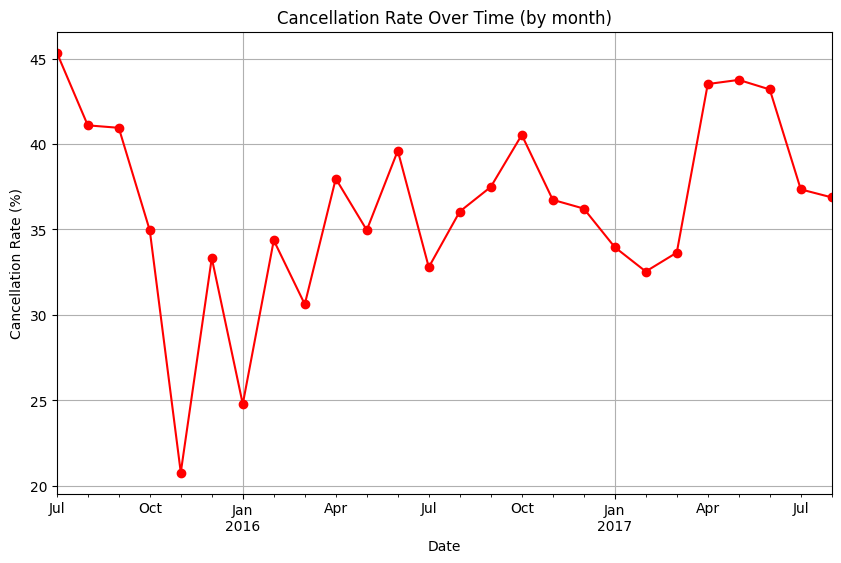

In [11]:
# Columns I need to visualize my data:
    # Cancellation rate over time (by month)
        # is_canceled
        # arrival_date_year
        # arrival_date_month
            # optional 
                # hotel 
                # market_segment
                # customer_type
                # distribution_channel

# Created a single datetime column using month and year then convert into integers
df["arrival_month_year"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" +
    df["arrival_date_month"] + "-01"
)

df["arrival_month_year"].dtype
df[["arrival_date_year", "arrival_date_month", "arrival_month_year"]].head()

# Now, I must prepare the data for monthly aggregation 
# Set the date column as the DataFrame index for easy time-series functionality
df.set_index('arrival_month_year', inplace=True)

# Now Iw ant to resample to 'MS' for month start frequency and aggregate the data
# So I calculate the sum of cancellations and the total count of orders for each month
monthly_data = df.resample('MS').agg(
    total_cancellations=('is_canceled', 'sum'),
    total_orders=('is_canceled', 'count')
)
# The is_canceled column is encoded as 0/1,
# which allows direct aggregation using sum and count
# to compute cancellation metrics.

# Finally, I want to calculate the cancellation rate (as a percentage)
monthly_data['cancellation_rate'] = (monthly_data['total_cancellations'] / monthly_data['total_orders']) * 100

monthly_data

# Plot the 'cancellation_rate'
plt.figure(figsize=(10, 6)) 
monthly_data['cancellation_rate'].plot(kind='line', marker='o', color='red') 

plt.title('Cancellation Rate Over Time (by month)')
plt.xlabel('Date')
plt.ylabel('Cancellation Rate (%)')
plt.grid(True) 

plt.show()


Cancellation rates fluctuate seasonally which peak during mid-year months, suggesting time-based demand uncertainty.

## Cancellation rate by hotel type

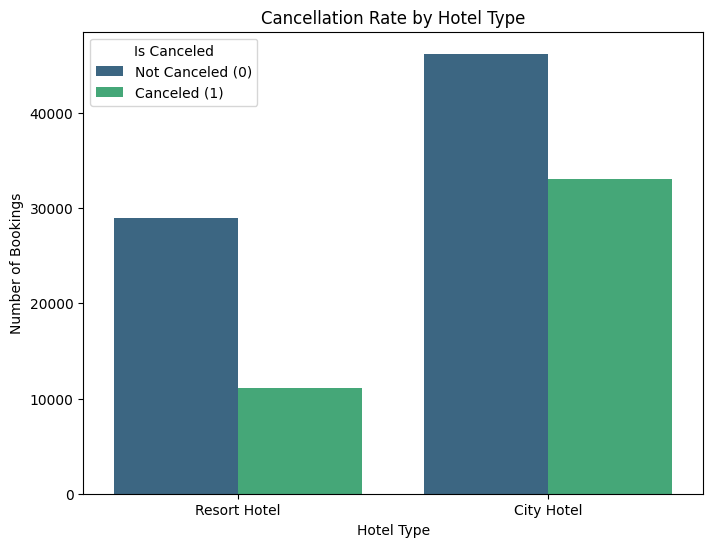

In [12]:
# Columns I need to visualize my data:
    # Cancellation rate by hotel type
        # hotel
        # is_canceled

plt.figure(figsize=(8, 6))
sb.countplot(x='hotel', hue='is_canceled', data=df, palette='viridis') 
plt.title('Cancellation Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.legend(title='Is Canceled', labels=['Not Canceled (0)', 'Canceled (1)'])
plt.show()


City Hotels exhibit a higher cancellation rate than Resort Hotels, which suggests greater booking volatility in urban markets.

## Cancellation rate by market segment

/var/folders/ml/pkr27nwj14j_z_0bgf5tf4x40000gn/T/ipykernel_1401/2200032567.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(


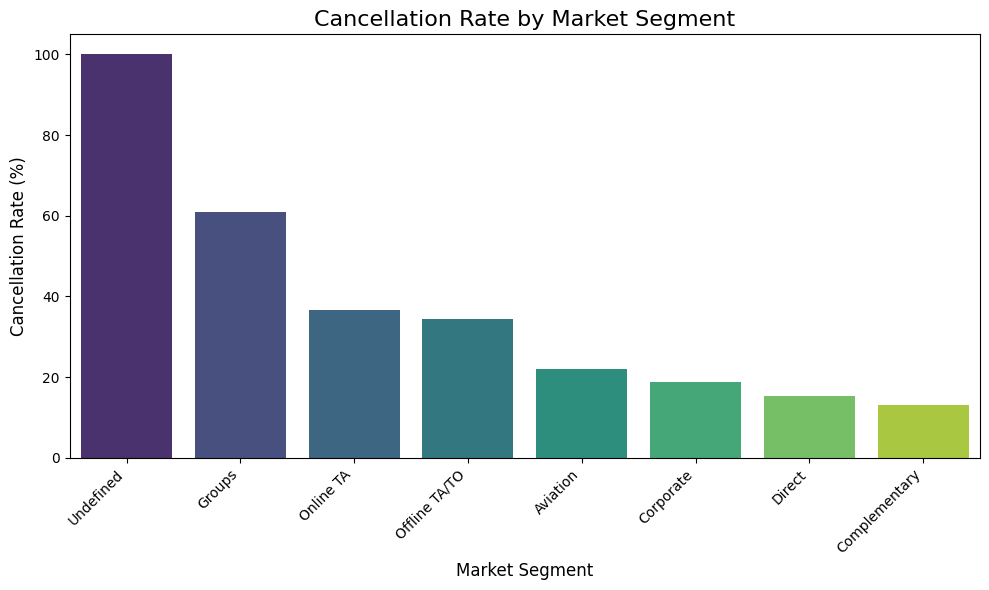

In [13]:
# Columns I need to visualize my data:
    # Cancellation rate over time (by month)
        # is_canceled
        # market_segment

# Calculating the cancellation rate per segment
segment_cancellation_rate = df.groupby('market_segment')['is_canceled'].mean().reset_index()

# Convert for better readability
segment_cancellation_rate['cancellation_rate_pct'] = segment_cancellation_rate['is_canceled'] * 100

# Sort for better visualization (optional)
segment_cancellation_rate = segment_cancellation_rate.sort_values('cancellation_rate_pct', ascending=False)

# 3. Visualize with a Bar Chart
plt.figure(figsize=(10, 6))
sb.barplot(
    data=segment_cancellation_rate,
    x='market_segment',
    y='cancellation_rate_pct',
    palette='viridis' 
)

plt.title('Cancellation Rate by Market Segment', fontsize=16)
plt.xlabel('Market Segment', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout() 
plt.show()

Group reservations are more likely to cancel due to multi-party coordination and advance planning risks.

## Lead time vs cancellation

/var/folders/ml/pkr27nwj14j_z_0bgf5tf4x40000gn/T/ipykernel_1401/413739295.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_lt.groupby("lead_time_bin")["is_canceled"]


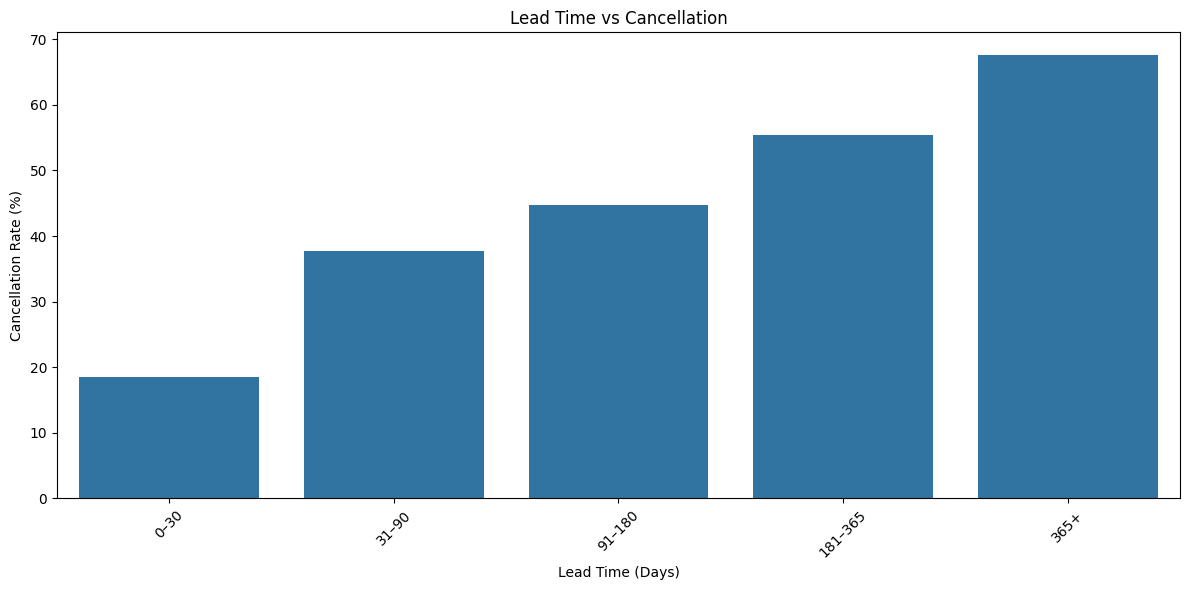

In [14]:
# Columns I need to visualize my data:
    # Lead time vs cancellation
        # is_canceled
        # lead_time

df["lead_time"].dtype

# Keeping only the columns we need & drop missing
df_lt = df[["lead_time", "is_canceled"]].dropna()

# Make sure types are clean
df_lt["lead_time"] = pd.to_numeric(df_lt["lead_time"], errors="coerce")
df_lt["is_canceled"] = pd.to_numeric(df_lt["is_canceled"], errors="coerce")

df_lt = df_lt.dropna(subset=["lead_time", "is_canceled"])

# Bin lead-times for easier restructuring
bins = [0, 30, 90, 180, 365, df_lt["lead_time"].max()]
labels = ["0–30", "31–90", "91–180", "181–365", "365+"]

df_lt["lead_time_bin"] = pd.cut(
    df_lt["lead_time"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Cancellation rate per bin
leadtime_cancel_rate = (
    df_lt.groupby("lead_time_bin")["is_canceled"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="cancellation_rate_pct")
)

leadtime_cancel_rate

# Plot
plt.figure(figsize=(12, 6))
sb.barplot(x="lead_time_bin", y="cancellation_rate_pct", data=leadtime_cancel_rate)
plt.title("Lead Time vs Cancellation")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Longer lead times are associated with higher cancellation rates, suggesting early bookings carry greater uncertainty.

## ADR vs cancellation

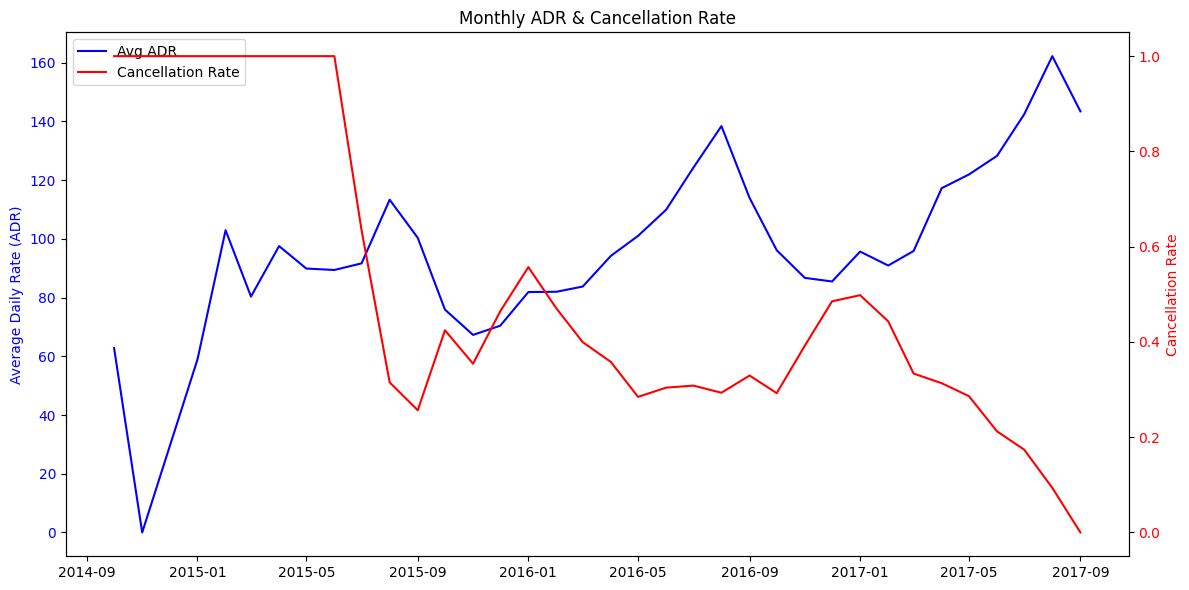

In [15]:
# Columns I need to visualize my data:
    # Cancellation rate over time (by month)
        # is_canceled
        # adr

#df["reservation_status_date"].dtype
#df["adr"].dtype

# Ensure date and numeric types
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])
df['adr'] = pd.to_numeric(df['adr'])
df['is_canceled'] = df['is_canceled'].astype(int)

# Group & aggregate by month
monthly_data = df.groupby(df['reservation_status_date'].dt.to_period('M')).agg(
    avg_adr=('adr', 'mean'),
    total_bookings=('is_canceled', 'count'),
    canceled_bookings=('is_canceled', 'sum')
)
monthly_data['cancel_rate'] = monthly_data['canceled_bookings'] / monthly_data['total_bookings']


fig, ax1 = plt.subplots(figsize=(12, 6))

# Convert for cleaner plotting
if str(type(monthly_data.index)).find("PeriodIndex") != -1:
    plot_data = monthly_data.copy()
    plot_data.index = plot_data.index.to_timestamp()
else:
    plot_data = monthly_data

# Line 1: ADR
l1 = ax1.plot(plot_data.index, plot_data["avg_adr"], color="blue", label="Avg ADR")
ax1.set_ylabel("Average Daily Rate (ADR)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Line 2: Cancellation rate
ax2 = ax1.twinx()
l2 = ax2.plot(plot_data.index, plot_data["cancel_rate"], color="red", label="Cancellation Rate")
ax2.set_ylabel("Cancellation Rate", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Combined legend
lines = l1 + l2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Monthly ADR & Cancellation Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Higher ADR months generally coincide with lower cancellation rates, which indicates price sensitivity among lower-value bookings.

## Summarize Your Results

With your EDA complete, answer the following questions.

1. Was there anything surprising about your dataset? 
- One surprise was the high consistency across cancellation amongst multiple dimensions. More specifically, for bookings with long lead times and certain market segments
- What surprised me most was that the undefined marke segment exhibited the highest cancellation rate, suggesting potential gaps in booking reservations 

2. Do you have any concerns about your dataset? 
- The presence of an undefined market segment indicated incomplete or even missing data. This could affect the reliability of segment-level conclusions
- There are a few outliers within ADR that may skew summary statistics
- Some columns require careful type handling to ensure more accuracy

3. Is there anything you want to make note of for the next phase of your analysis, which is cleaning data? 
- In the next phase, it'll be important to address any missing values
- Outliers in ADR will need to be reviewed and maybe capped or filtered depending on relevance
- Date fields will need to be standardized 